## 1) Loading and preprocessing the dataset

In [10]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt

# Load Iris dataset
from sklearn.datasets import load_iris

# Load dataset
iris = load_iris()

# Create DataFrame
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Add species column temporarily
df['species'] = iris.target

# Display first 5 rows
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [11]:
# Drop species column since clustering is unsupervised learning
X = df.drop('species', axis=1)

# Display dataset
X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


## Clustering Algorithm implementation

### 1) KMeans Clustering 

#### Brief Description
KMeans clustering is an unsupervised machine learning algorithm that groups data into K clusters based on similarity. 

The algorithm works by:

Selecting K centroids randomly. Assigning each data point to the nearest centroid. 
Updating the centroids based on cluster mean. Repeating the process until convergence


#### Why KMeans is Suitable for Iris Dataset
 
Iris dataset contains naturally separable flower groups. Features like petal length and petal width help distinguish clusters clearly. KMeans works well for compact and spherical clusters. The dataset size is small and easy to cluster efficiently

In [12]:
from sklearn.cluster import KMeans

# Create KMeans model
kmeans = KMeans(n_clusters=3, random_state=42)

# Fit and predict clusters
kmeans_clusters = kmeans.fit_predict(X)

# Add cluster labels
X['KMeans_Cluster'] = kmeans_clusters

# Display clustered data
X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),KMeans_Cluster
0,5.1,3.5,1.4,0.2,1
1,4.9,3.0,1.4,0.2,1
2,4.7,3.2,1.3,0.2,1
3,4.6,3.1,1.5,0.2,1
4,5.0,3.6,1.4,0.2,1


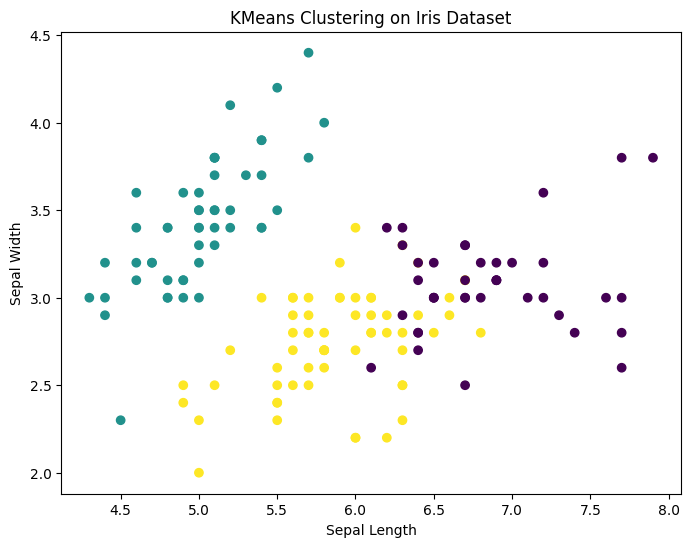

In [13]:
plt.figure(figsize=(8,6))

plt.scatter(
    X.iloc[:, 0],
    X.iloc[:, 1],
    c=kmeans_clusters,
    cmap='viridis'
)

plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.title('KMeans Clustering on Iris Dataset')

plt.show()

### 2) Hierarchial Clustering

#### Brief Description

Hierarchical clustering is an unsupervised learning algorithm that builds clusters in a tree-like structure called a dendrogram.

There are two approaches:

Agglomerative (bottom-up)
Divisive (top-down)

Agglomerative clustering starts with individual data points and merges the closest clusters step by step.


#### Why Hierarchical Clustering is Suitable for Iris Dataset

It helps visualize relationships between flower samples. No need to initialize centroids .Works well for small datasets like Iris .Dendrogram provides clear cluster structure

In [14]:
from sklearn.cluster import AgglomerativeClustering

# Create hierarchical clustering model
hc = AgglomerativeClustering(n_clusters=3)

# Predict clusters
hc_clusters = hc.fit_predict(df.drop('species', axis=1))

# Add cluster labels
df['Hierarchical_Cluster'] = hc_clusters

# Display clustered data
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,Hierarchical_Cluster
0,5.1,3.5,1.4,0.2,0,1
1,4.9,3.0,1.4,0.2,0,1
2,4.7,3.2,1.3,0.2,0,1
3,4.6,3.1,1.5,0.2,0,1
4,5.0,3.6,1.4,0.2,0,1


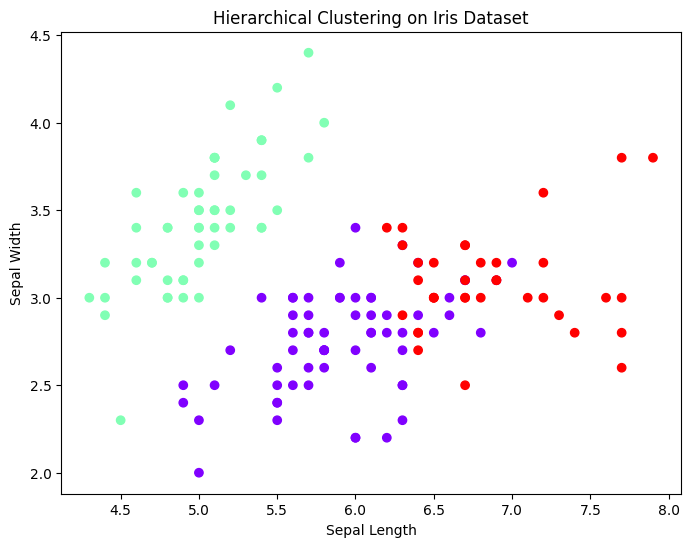

In [15]:
plt.figure(figsize=(8,6))

plt.scatter(
    df.iloc[:, 0],
    df.iloc[:, 1],
    c=hc_clusters,
    cmap='rainbow'
)

plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.title('Hierarchical Clustering on Iris Dataset')

plt.show()

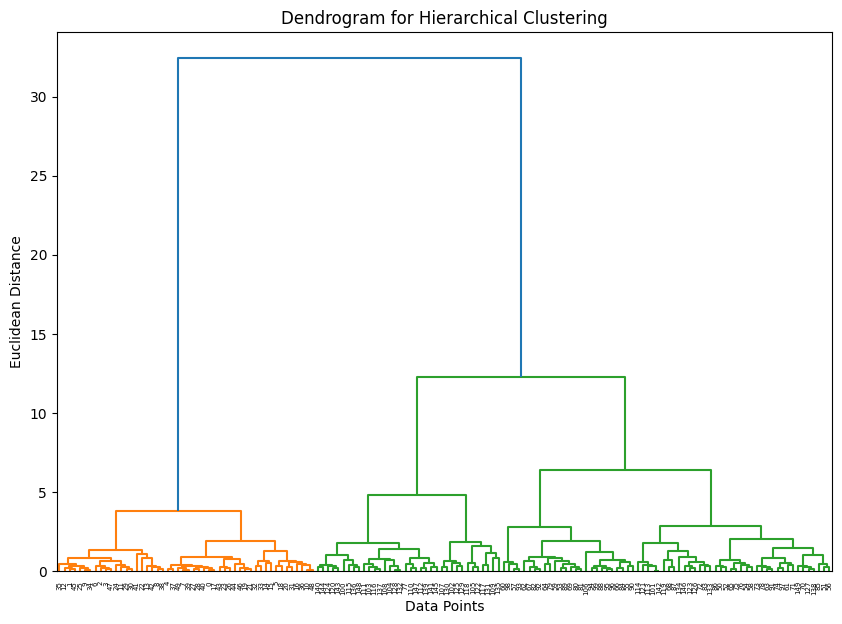

In [16]:
from scipy.cluster.hierarchy import dendrogram, linkage

# Generate linkage matrix
linked = linkage(df.drop(['species', 'Hierarchical_Cluster'], axis=1), method='ward')

# Plot dendrogram
plt.figure(figsize=(10,7))

dendrogram(linked)

plt.title('Dendrogram for Hierarchical Clustering')
plt.xlabel('Data Points')
plt.ylabel('Euclidean Distance')

plt.show()

## Conclusion

KMeans clustering grouped the Iris flowers into 3 clusters efficiently.
Hierarchical clustering also identified meaningful clusters and provided a dendrogram visualization.
Both algorithms performed well on the Iris dataset due to its naturally separable structure.